In [6]:
import numpy as np
import os

import random
import pandas as pd
import math
import matplotlib.pyplot as plt


import astropy.units as u
import matplotlib.ticker as mtick
import glob as glob
import astropy.constants as const

In [2]:
import sys
#from general_function import *


In [3]:
binnum = 100

EFFICIENCY_folder = './detector_efficiency'

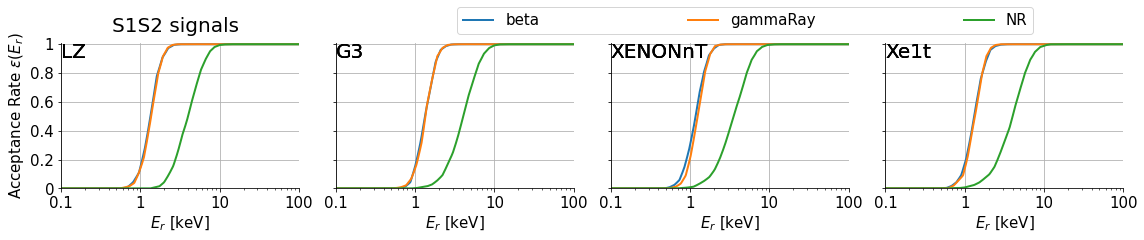

In [9]:
detectors = ['LZ', 'G3', 'XENONnT', 'Xe1t', 'Xe100t_5']
interactions = ['beta', 'gammaRay', 'NR']
signal_type = 'S1S2'
keV = np.logspace(-3, np.log10(1000), 1000) * u.keV
fig, ax = plt.subplots(1, len(detectors),  
                       figsize = (4*len(detectors), 3), sharey = True, sharex = True)
xlabel = r'$E_{r}$ [keV]'
for d, detector in enumerate(detectors):
    for i, interaction in enumerate(interactions):
        FILE_NAME = 'det_eff_'+detector+'_'+interaction+'.csv'
        file = os.path.join(EFFICIENCY_folder,FILE_NAME)
        
        df_eff = pd.read_csv(file, header = 0, index_col = 0)
        E = df_eff['E_center [keV]']
        
        eff = df_eff['eff '+signal_type]
       
        f = interp1d(E, eff, fill_value=(0, list(eff)[-1]), bounds_error=False)
        Efficiency_fn = f(keV.value)

        ax[d].semilogx(keV, Efficiency_fn, lw = 2, label = interaction)


        if d == 0:
            ylabel = r'Acceptance Rate $\epsilon(E_{r})$'
        else:
            ylabel = ''
        ax[d] = setup_cdfpdf_ax(ax[d] , '', xlabel , ylabel, True, '', 15,15, 
              vlines = [0], hlines = [0], xlims = [0.1,100], ylims = [0,1.01], log = [1,0])
        ax[d].text(ax[d].get_xlim()[0], ax[d].get_ylim()[-1], detector, 
                   horizontalalignment='left', verticalalignment='top', fontsize = 20)
        
        
        ax[d].set_xticks([0.1, 1, 10, 100])
        formatter = mtick.ScalarFormatter()
        formatter.set_scientific(False)
        ax[d].xaxis.set_major_formatter(formatter)
        ax[d].xaxis.set_major_formatter(mtick.FormatStrFormatter('%1g'))
        
        ax[d].set_yticks([0, 0.2, 0.4,0.6, 0.8,1])
        ax[d].yaxis.set_major_formatter(mtick.FormatStrFormatter('%1g'))
        ax[d].spines['right'].set_visible(False)
        ax[d].spines['top'].set_visible(False)
fig.tight_layout()    
fig.suptitle('S1S2 signals', fontsize = 20, x = 0.1, y= 1.05, horizontalalignment = 'left')

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           bbox_to_anchor=(0.4, 0.97, 0.5, .102), loc='lower left',
           ncol=3, mode="expand", borderaxespad=0., 
           fontsize = 15)
          

det_eff_LZ_beta
./detector_efficiency/det_eff_LZ_beta.csv
det_eff_G3_beta
./detector_efficiency/det_eff_G3_beta.csv
det_eff_XENONnT_beta
./detector_efficiency/det_eff_XENONnT_beta.csv
det_eff_Xe1t_beta
./detector_efficiency/det_eff_Xe1t_beta.csv
det_eff_Xe100t-5_beta
./detector_efficiency/det_eff_Xe100t-5_beta.csv
det_eff_LZ_NR
./detector_efficiency/det_eff_LZ_NR.csv
det_eff_G3_NR
./detector_efficiency/det_eff_G3_NR.csv
det_eff_XENONnT_NR
./detector_efficiency/det_eff_XENONnT_NR.csv
det_eff_Xe1t_NR
./detector_efficiency/det_eff_Xe1t_NR.csv
det_eff_Xe100t-5_NR
./detector_efficiency/det_eff_Xe100t-5_NR.csv
det_eff_LZ_gammaRay
./detector_efficiency/det_eff_LZ_gammaRay.csv
det_eff_G3_gammaRay
./detector_efficiency/det_eff_G3_gammaRay.csv
det_eff_XENONnT_gammaRay
./detector_efficiency/det_eff_XENONnT_gammaRay.csv
det_eff_Xe1t_gammaRay
./detector_efficiency/det_eff_Xe1t_gammaRay.csv
det_eff_Xe100t-5_gammaRay
./detector_efficiency/det_eff_Xe100t-5_gammaRay.csv


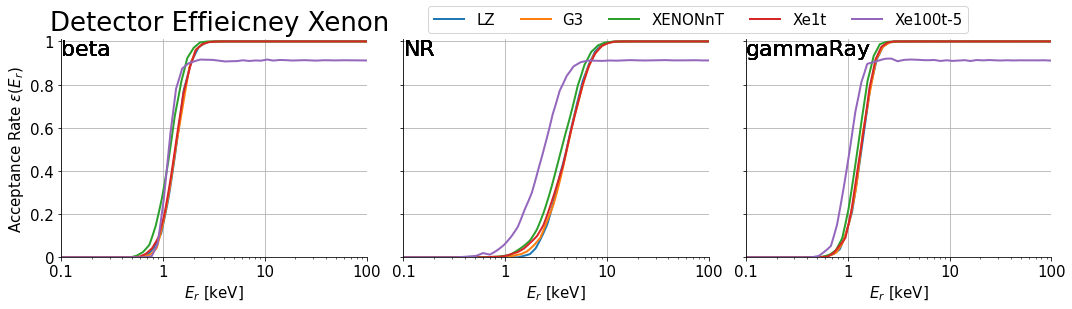

In [24]:
detectors = ['LZ', 'G3', 'XENONnT', 'Xe1t', 'Xe100t-5']
interactions = ['beta', 'NR', 'gammaRay']

keV = np.logspace(-3, np.log10(1000), 1000) * u.keV
fig, ax = plt.subplots(1, len(interactions),  
                       figsize = (5*len(interactions), 4), sharey = True, sharex = True)
xlabel = r'$E_{r}$ [keV]'
for i, interaction in enumerate(interactions):
    for d, detector in enumerate(detectors):
    
        Efficiency_fn = get_detector_efficiency(keV, detector, interaction, 
                                                det_eff_folder ='./detector_efficiency',signal_type = 'S1S2',
                            plot_eff = False)

        ax[i].semilogx(keV, Efficiency_fn, lw = 2, label = detector)


        if i == 0:
            ylabel = r'Acceptance Rate $\epsilon(E_{r})$'
        else:
            ylabel = ''
        ax[i] = setup_cdfpdf_ax(ax[i] , '', xlabel , ylabel, True, '', 15,15, 
              vlines = [0], hlines = [0], xlims = [0.1,100], ylims = [0,1.01], log = [1,0])
        ax[i].text(ax[i].get_xlim()[0], ax[i].get_ylim()[-1], interaction, 
                   horizontalalignment='left', verticalalignment='top', fontsize = 22)
        
        
        ax[i].set_xticks([0.1, 1, 10, 100])
        formatter = mtick.ScalarFormatter()
        formatter.set_scientific(False)
        ax[i].xaxis.set_major_formatter(formatter)
        ax[i].xaxis.set_major_formatter(mtick.FormatStrFormatter('%1g'))
        
        ax[i].set_yticks([0, 0.2, 0.4,0.6, 0.8,1])
        ax[i].yaxis.set_major_formatter(mtick.FormatStrFormatter('%1g'))
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['top'].set_visible(False)
fig.tight_layout()    
fig.suptitle('Detector Effieicney Xenon', fontsize = 26, x = 0.05, y= 1.05, horizontalalignment = 'left')# S1S2 signals

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels,
           bbox_to_anchor=(0.4, 0.97, 0.5, .102), loc='lower left',
           ncol=5, mode="expand", borderaxespad=0., 
           fontsize = 15
          )
          

In [25]:
save_name = os.path.join('FIGURES', 
                         'detector_efficiency_interactions_Xenon.pdf')

print(save_name)


FIGURES/detector_efficiency_interactions_Xenon.pdf


In [26]:
fig.savefig(save_name , bbox_inches='tight')


In [12]:
def get_detector_efficiency(Es_keV, detector, interaction, det_eff_folder ='../detector_efficiency',signal_type = 'S1S2',
                            plot_eff = False):
    if detector == 'LUX03':
        A = 17.106
        B = 1.8223
        C = 0.65911
        D = 18.292
        E = 20869
        F = -2.35
        Efficiency_fn  = 10 ** ( 2 - A * np.exp ( -B * Es_keV ** C) - D * np.exp( -E * Es_keV ** F ) ) /100
        #where A,B,C,D,E,F are free parameters
    else:
        det_eff_info = 'det_eff_'+detector+'_'+interaction
        print(det_eff_info)
        det_eff_files = glob.glob(os.path.join(det_eff_folder, det_eff_info+'.*'))
        if len(det_eff_files) == 1:
            det_eff_file = det_eff_files[0]
            print(det_eff_file)
            if 'csv' in det_eff_file:
                df_eff = pd.read_csv(det_eff_file, header = 0, index_col = 0)

                effieicney_keV = list(df_eff['E_center [keV]'])      
                EFF = list(df_eff['eff '+signal_type])
            elif 'txt' in det_eff_file:
                effieicney_keV, EFF = read_file_dataline(det_eff_file)
            
            
            f = interp1d(effieicney_keV, EFF, fill_value=(0, EFF[-1]), bounds_error=False)
            Efficiency_fn = f(Es_keV)
        
        
        elif 'ideal' in detector and 'Ethrd' in detector:
            effieicney_keV = np.logspace(np.log10(min(Es_keV.value)), np.log10(max(Es_keV.value)), 1001)*Es_keV.unit
            Ethrd = float(detector.split('Ethrd')[-1][:-3])*u.keV
            print('ideal detector with threshold ', Ethrd)
            EFF = np.heaviside(effieicney_keV-Ethrd, 1.)
            f = interp1d(effieicney_keV, EFF, fill_value=(0, EFF[-1]), bounds_error=False)
            Efficiency_fn = f(Es_keV)
        else:
            print(det_eff_files)
            print('no file available')
        
        '''
        if os.path.exists(det_eff_file) == True:
            df_eff = pd.read_csv(det_eff_file, header = 0, index_col = 0)

            effieicney_keV = list(df_eff['E_center [keV]'])      
            EFF = list(df_eff['eff '+signal_type])
        else:
            det_eff_files = glob.glob(os.path.join(det_eff_folder, det_eff_info+'.txt'))
            
            if len(det_eff_files) == 1:
                effieicney_keV, EFF = read_file_dataline(det_eff_files[0])
                #print(effieicney_keV, EFF )
        
        f = interp1d(effieicney_keV, EFF, fill_value=(0, EFF[-1]), bounds_error=False)
        Efficiency_fn = f(Es_keV)
        '''
    if plot_eff:
        fig, ax = plt.subplots()
        ax.plot(effieicney_keV, EFF)
    return Efficiency_fn 


det_eff_ideal Ethrd1keV_beta
ideal detector with threshold  1.0 keV
det_eff_Argon-Darkside_NR
./detector_efficiency/det_eff_Argon-Darkside_NR.txt


'\nfig.legend(handles, labels,\n           bbox_to_anchor=(0.4, 0.97, 0.5, .102), loc=\'lower left\',\n           ncol=5, mode="expand", borderaxespad=0., \n           fontsize = 15\n          )\n'

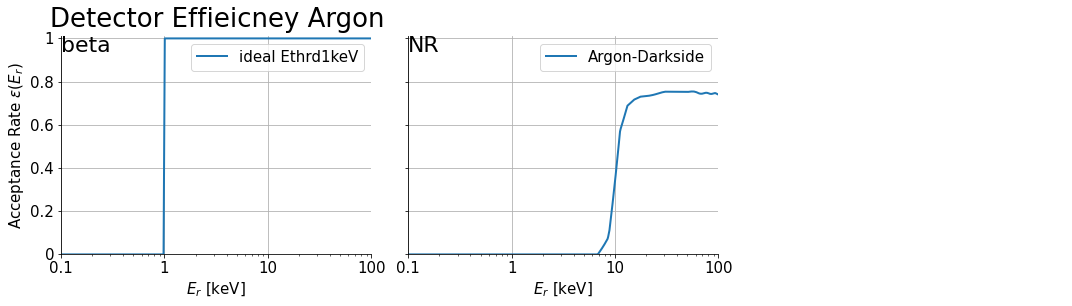

In [32]:
detectors = ['ideal Ethrd1keV','Argon-Darkside' ]#
interactions = ['beta', 'NR']
signal_type = 'S1S2'
handles, labels = [], []
keV = np.logspace(-3, np.log10(1000), 1000) * u.keV
fig, ax = plt.subplots(1, len(interactions)+1,  
                       figsize = (5*(len(interactions)+1), 4), sharey = True, sharex = True)
xlabel = r'$E_{r}$ [keV]'
for i, (interaction, detector) in enumerate(zip(interactions, detectors)):
        
        Efficiency_fn = get_detector_efficiency(keV, detector, interaction, 
                                                det_eff_folder ='./detector_efficiency',signal_type = 'S1S2',
                            plot_eff = False)
        
        ax[i].semilogx(keV, Efficiency_fn, lw = 2, label = detector)


        if i == 0:
            ylabel = r'Acceptance Rate $\epsilon(E_{r})$'
        else:
            ylabel = ''
        ax[i] = setup_cdfpdf_ax(ax[i] , '', xlabel , ylabel, True, '', 15,15, 
              vlines = [0], hlines = [0], xlims = [0.1,100], ylims = [0,1.01], log = [1,0])
        ax[i].text(ax[i].get_xlim()[0], ax[i].get_ylim()[-1], interaction, 
                   horizontalalignment='left', verticalalignment='top', fontsize = 22)
        
        
        ax[i].set_xticks([0.1, 1, 10, 100])
        formatter = mtick.ScalarFormatter()
        formatter.set_scientific(False)
        ax[i].xaxis.set_major_formatter(formatter)
        ax[i].xaxis.set_major_formatter(mtick.FormatStrFormatter('%1g'))
        
        ax[i].set_yticks([0, 0.2, 0.4,0.6, 0.8,1])
        ax[i].yaxis.set_major_formatter(mtick.FormatStrFormatter('%1g'))
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['top'].set_visible(False)
        ax[i].legend(fontsize = 15)
        #handle, label = ax[i].get_legend_handles_labels()
        #handles.extend(handle)
        #labels.extend(label)
ax[-1].axis('off')        
fig.tight_layout()    
fig.suptitle('Detector Effieicney Argon', fontsize = 26, x = 0.05, y= 1.05, horizontalalignment = 'left')# S1S2 signals

'''
fig.legend(handles, labels,
           bbox_to_anchor=(0.4, 0.97, 0.5, .102), loc='lower left',
           ncol=5, mode="expand", borderaxespad=0., 
           fontsize = 15
          )
'''

In [33]:
save_name = os.path.join('FIGURES', 
                         'detector_efficiency_interactions_Argon.pdf')

print(save_name)


FIGURES/detector_efficiency_interactions_Argon.pdf


In [34]:
fig.savefig(save_name , bbox_inches='tight')
